In [1]:
import pickle

with open("./datasets/lubm/example_star_dataset_compact_implicit_join.pkl", "rb") as f:
	dataset = zip(*pickle.load(f))

c:\user\projects\thesis\new_repo\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dataset = [*zip(*dataset)]
dataset[0]

(['?s <http://example.org/6> <http://example.org/133531>.',
  '?s <http://example.org/3> ?o2.',
  '?s <http://example.org/8> <http://example.org/87855>.',
  '?s <http://example.org/2> ?o1.',
  '?s <http://example.org/6> ?o3.',
  '?s <http://example.org/6> <http://example.org/27303>.',
  '?s <http://example.org/4> <http://example.org/161290>.',
  '?s <http://example.org/7> <http://example.org/28>.'],
 Data(x=[8, 306], edge_index=[2, 7], y=[1]))

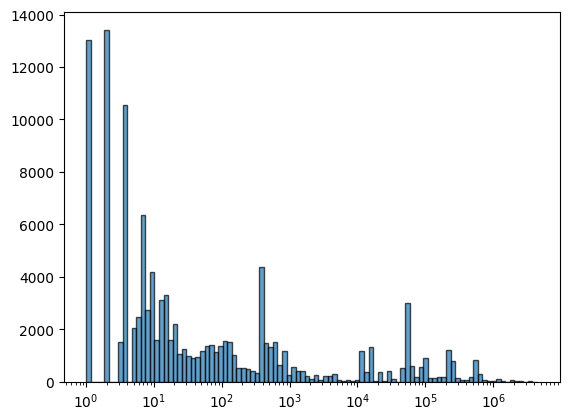

In [3]:
import numpy as np
from matplotlib import pyplot as plt

costs = [datapoint[1].y for datapoint in dataset]
logspace = np.logspace(min(costs).log(), max(costs).log(), 100, base=np.e).reshape(-1)
hist, edge = np.histogram(costs, bins=logspace)

plt.bar(edge[:-1], hist, width=np.diff(edge), align='edge', edgecolor='black', alpha=0.7)
plt.xscale('log')

In [11]:
bins = [[] for _ in range(len(hist))]
for triple, datapoint in dataset:
	box_index = next(i for i in range(len(hist)) if logspace[i] <= datapoint.y <= logspace[i + 1])
	bins[box_index].append((triple, datapoint))

In [12]:
middle_point = int(len(dataset) / len(hist))
middle_point

1150

In [13]:
import random
random.seed(42)

result = []

for i in range(len(bins)):
	bin = bins[i]
	if len(bin) == 0:
		continue
	if len(bin) > middle_point:
		random.shuffle(bin)
		res_bin = bin[:middle_point]
	elif len(bin) < middle_point:
		res_bin = bin + random.choices(bin, k=middle_point - len(bin))
	else:
		res_bin = bin
	result.append(res_bin)

In [14]:
uniform_dataset = sum(result, start=[])

In [15]:
sum(len(bin) for bin in result), len(uniform_dataset), len(dataset), len(uniform_dataset) - len(dataset)

(106950, 106950, 113855, -6905)

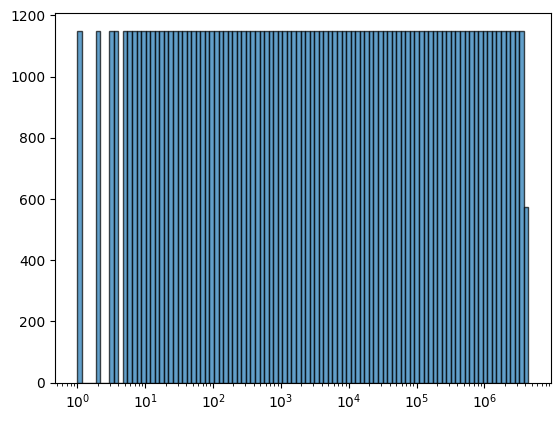

In [16]:
import numpy as np
from matplotlib import pyplot as plt

costs = [datapoint.y.item() for _, datapoint in uniform_dataset]
hist, edge = np.histogram(costs, bins=logspace)

plt.bar(edge[:-1], hist, width=np.diff(edge), align='edge', edgecolor='black', alpha=0.7)
plt.xscale('log')

In [18]:
import pickle

with open("./datasets/lubm/example_star_dataset_compact_implicit_join_balanced.pkl", "wb") as f:
	pickle.dump(tuple(zip(*uniform_dataset)), f)